<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 105 · The Machine Learning Workflow</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Machine Learning Workflow</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The disciplined process end to end on a loan-default table: split first, expose overfitting with a validation curve, estimate with cross-validation, tune with GridSearchCV, prevent leakage with pipelines, and evaluate once on held-out data, library-first and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# The Machine Learning Workflow, end to end
A model is only as trustworthy as the process around it. This notebook runs the full workflow on a loan-default table: **split off a test set first**, expose **overfitting** with a validation curve, estimate honestly with **cross-validation**, tune with **GridSearchCV**, wrap preprocessing in a **Pipeline**, catch **data leakage** in the act, and evaluate **once** on held-out data. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; SPLIT OFF A TEST SET FIRST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Lock the test data away before anything else</div>
<div style="color:#4a5578;margin-top:6px">Every honest workflow starts here.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/ch105_loans.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'ch105_loans.xlsx', sheet_name='Data')
feat = ['income_k','loan_amount_k','term_months','credit_score','age','employment_years',
        'debt_to_income','num_open_accounts','prior_defaults','late_payments_12m']
X, y = df[feat], df['default']
leak_col = df['sent_to_collections']   # kept aside for the leakage demo (DEMO 5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)
print(f'{len(X_train)} training rows, {len(X_test)} test rows locked away (default rate {y.mean():.0%})')

750 training rows, 250 test rows locked away (default rate 59%)


**The first rule of the workflow.** Before exploring, scaling, or modeling, we **hold out a test set** and do not look at it again until the very end. The `stratify=y` argument keeps the default rate identical in both parts. From here on, all decisions, feature choices, tuning, model selection, use the **training data only**. Touching the test set early is how people fool themselves.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; WHY TRAINING ACCURACY LIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Overfitting, seen with a validation curve</div>
<div style="color:#4a5578;margin-top:6px">A model can ace the training data and still fail on new data.</div>
</div>

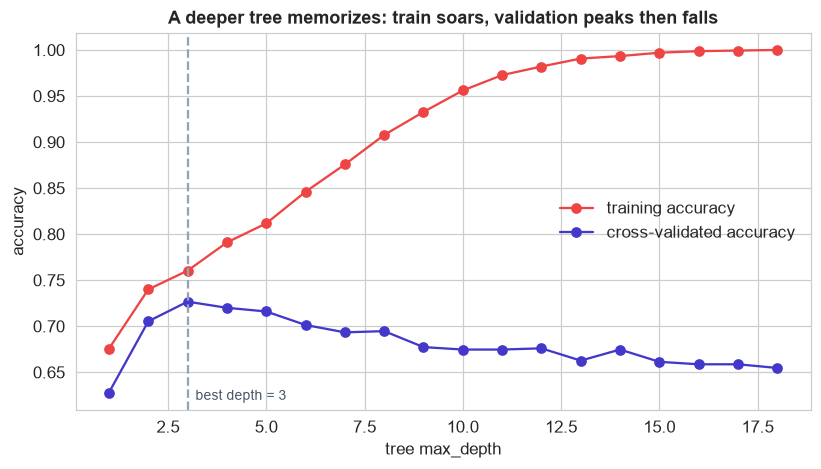

deepest tree: train 1.00 vs validation 0.65  <- the overfitting gap


In [4]:
depths = list(range(1, 19))
train_sc, val_sc = validation_curve(DecisionTreeClassifier(random_state=0), X_train, y_train,
                                    param_name='max_depth', param_range=depths, cv=5, scoring='accuracy')
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.plot(depths, train_sc.mean(axis=1), 'o-', color=RED, label='training accuracy')
ax.plot(depths, val_sc.mean(axis=1), 'o-', color=EM, label='cross-validated accuracy')
best = depths[int(np.argmax(val_sc.mean(axis=1)))]
ax.axvline(best, color=GREY, ls='--'); ax.text(best+0.2, 0.62, f'best depth = {best}', color=SLATE, fontsize=9)
ax.set(title='A deeper tree memorizes: train soars, validation peaks then falls', xlabel='tree max_depth', ylabel='accuracy'); ax.legend()
plt.tight_layout(); plt.show()
print(f'deepest tree: train {train_sc.mean(axis=1)[-1]:.2f} vs validation {val_sc.mean(axis=1)[-1]:.2f}  <- the overfitting gap')

**What the code does.** `validation_curve` refits a decision tree at each `max_depth` and records training and cross-validated accuracy. **Reading the plot:** as the tree deepens, **training accuracy climbs toward 100%** because the model memorizes individual rows, but **cross-validated accuracy peaks and then declines**, the classic signature of **overfitting**. The gap between the two curves is the tell. The best depth is the top of the blue cross-validated curve, complex enough to learn the pattern, simple enough to generalize.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; CROSS-VALIDATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One split is noisy; k folds are stable</div>
<div style="color:#4a5578;margin-top:6px">Rotate the validation set through the data.</div>
</div>

5 fold accuracies: [0.747 0.673 0.76  0.727 0.733]
mean = 0.728  std = 0.030


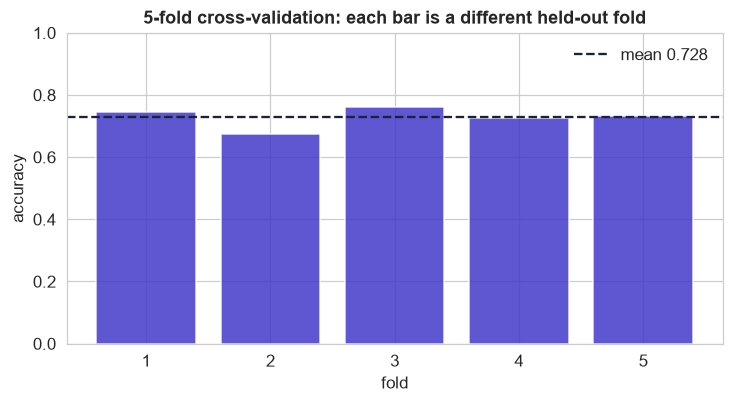

In [5]:
model = DecisionTreeClassifier(max_depth=best, random_state=0)
scores = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0))
print('5 fold accuracies:', np.round(scores, 3))
print(f'mean = {scores.mean():.3f}  std = {scores.std():.3f}')
fig, ax = plt.subplots(figsize=(6.8,3.8))
ax.bar(range(1,6), scores, color=EM, alpha=0.85)
ax.axhline(scores.mean(), color=INK, ls='--', label=f'mean {scores.mean():.3f}')
ax.set(title='5-fold cross-validation: each bar is a different held-out fold', xlabel='fold', ylabel='accuracy', ylim=(0,1)); ax.legend()
plt.tight_layout(); plt.show()

**What the code does.** `cross_val_score` with `StratifiedKFold(5)` splits the training data into five folds, trains on four and scores on the fifth, five times, so **every row is validated once**. The **mean** is a far more stable estimate than any single split, and the **standard deviation** tells you how much that estimate wobbles. This is how we compare models and settings without ever touching the locked test set.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; HYPERPARAMETER TUNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Let the data choose the settings</div>
<div style="color:#4a5578;margin-top:6px">GridSearchCV searches a grid with cross-validation.</div>
</div>

best params: {'max_depth': 4, 'min_samples_leaf': 20}  best CV accuracy: 0.736


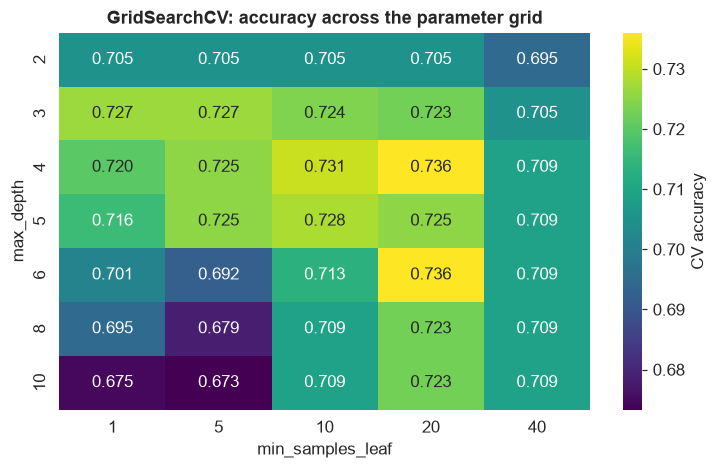

In [6]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=0),
                    {'max_depth':[2,3,4,5,6,8,10], 'min_samples_leaf':[1,5,10,20,40]},
                    cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print('best params:', grid.best_params_, f' best CV accuracy: {grid.best_score_:.3f}')
piv = pd.DataFrame(grid.cv_results_).pivot_table(index='param_max_depth', columns='param_min_samples_leaf', values='mean_test_score')
fig, ax = plt.subplots(figsize=(6.8,4.4))
sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label':'CV accuracy'}, ax=ax)
ax.set(title='GridSearchCV: accuracy across the parameter grid', xlabel='min_samples_leaf', ylabel='max_depth')
plt.tight_layout(); plt.show()

**What the code does.** `GridSearchCV` tries every combination of `max_depth` and `min_samples_leaf`, cross-validating each, and keeps the best. The heatmap shows the accuracy landscape: shallow trees underfit (top rows), and both very deep trees and tiny leaves overfit, the bright band is the sweet spot the search found automatically. `grid.best_params_` are the settings we will use; `random search` (`RandomizedSearchCV`) does the same when the grid is too large to enumerate.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; PIPELINES AND THE LEAKAGE TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The mistake that quietly inflates every score</div>
<div style="color:#4a5578;margin-top:6px">Preprocessing belongs inside cross-validation, and post-outcome features must be banned.</div>
</div>

honest model            : 0.713
with a leaky feature    : 0.948   <- looks amazing, but is a mirage


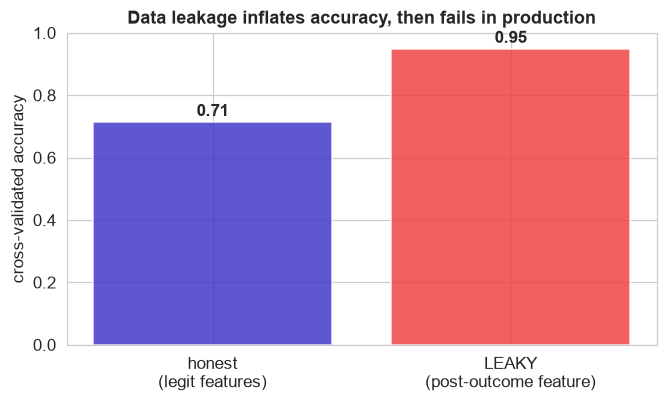

In [7]:
# CORRECT: a Pipeline fits the scaler INSIDE each CV fold, so no information leaks across folds
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))
honest = cross_val_score(pipe, X_train, y_train, cv=5).mean()
# TARGET LEAKAGE: sneak in 'sent_to_collections', which is only known AFTER default
X_leak = X_train.copy(); X_leak['sent_to_collections'] = leak_col.loc[X_train.index]
leaked = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)), X_leak, y_train, cv=5).mean()
print(f'honest model            : {honest:.3f}')
print(f'with a leaky feature    : {leaked:.3f}   <- looks amazing, but is a mirage')
fig, ax = plt.subplots(figsize=(6.2,3.8))
ax.bar(['honest\n(legit features)','LEAKY\n(post-outcome feature)'], [honest, leaked], color=[EM, RED], alpha=0.85)
ax.set(title='Data leakage inflates accuracy, then fails in production', ylabel='cross-validated accuracy', ylim=(0,1))
for i,v in enumerate([honest, leaked]): ax.text(i, v+0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

**Two leaks, one lesson.** **Preprocessing leakage:** if you scale (or impute, or select features) on the whole dataset before splitting, the training folds peek at the validation fold. Wrapping the steps in a **`Pipeline`** fixes this, the scaler is refit inside each fold. **Target leakage:** `sent_to_collections` is only recorded *after* a loan defaults, so it is almost a copy of the label; adding it rockets cross-validated accuracy, but at scoring time (a fresh application) the value does not exist, so the model would collapse. The rule: **a feature must be knowable at prediction time**, and all preprocessing must live inside the pipeline.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; THE FINAL, ONE-TIME TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Unlock the test set exactly once</div>
<div style="color:#4a5578;margin-top:6px">The honest estimate of real-world performance.</div>
</div>

held-out TEST accuracy = 0.744   (CV had estimated 0.736)


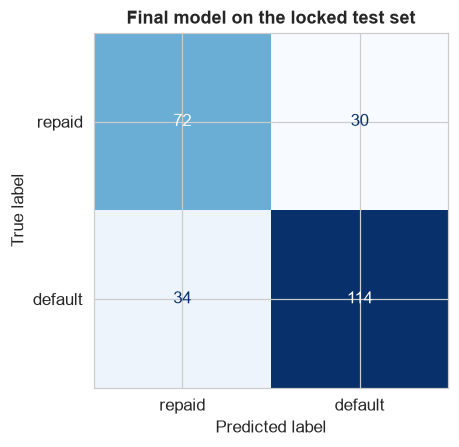

In [8]:
final = grid.best_estimator_.fit(X_train, y_train)   # refit the tuned model on all training data
test_pred = final.predict(X_test)
print(f'held-out TEST accuracy = {accuracy_score(y_test, test_pred):.3f}   (CV had estimated {grid.best_score_:.3f})')
fig, ax = plt.subplots(figsize=(4.8,4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=['repaid','default']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Final model on the locked test set'); plt.tight_layout(); plt.show()

**Closing the loop.** Only now, with the model and its settings fully chosen, do we unlock the **test set** and score once. The test accuracy lands close to the cross-validated estimate, evidence the whole process was honest and the model should perform similarly on genuinely new loans. If you tune against the test set and re-check repeatedly, that number becomes optimistic, which is exactly why it was locked away.

## The workflow in one checklist

1. **Split first**: hold out a test set (stratified) and do not touch it until the end.
2. **Explore and preprocess on training data only**, wrapped in a `Pipeline` so nothing leaks.
3. **Estimate honestly** with k-fold **cross-validation**, not a single split or the training score.
4. **Tune** hyperparameters with `GridSearchCV` / `RandomizedSearchCV` (cross-validated).
5. **Guard against leakage**: every feature must be knowable at prediction time; preprocessing lives inside the pipeline.
6. **Evaluate once** on the locked test set, then ship, monitor, and retrain.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>